In [130]:
####################################
#ENVIRONMENT SETUP

In [131]:
#LIBRARIES

#system
import os
import sys

#math and array operations
import numpy as np
import math
import pandas as pd

#data classes
import xarray as xr
import pickle

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import matplotlib.gridspec as gridspec

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#loading bar
from tqdm import tqdm

#datetime
from datetime import datetime

In [132]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [133]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "Observation_Data")
dataType = "RadarComparison"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER/RadarComparison



In [134]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [135]:
spinup_hours = "0"

RunType = ("TRACER","WET","NSSL",spinup_hours)
# RunType = ("TRACER","DRY","NSSL",spinup_hours)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

RunType = ("TRACER","WET","TEMPO",spinup_hours)
# RunType = ("TRACER","DRY","TEMPO",spinup_hours)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 193/193 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/history_cartesian/history.2022-07-01_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           WET
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-07-01 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:193
 # Diag Files:   193
 # Time Steps:   193
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs
 Static File:    TRACER_regional5250_scaled3_

In [136]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_MRMS_Class, RadarObservationMask_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [137]:
#Importing ERA5 Data Loading Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","ERA5_Data"))
from CLASSES_ERA5DataLoading import ERA5DataLoading_Class,ERA5DataLoading_Class_gdex

In [138]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSaving import DataSaving_Class

In [139]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Plotting import ContourPlotting_Class

In [172]:
####################################
#DATA LOADING

In [175]:
####################################
#CALCULATION FUNCTIONS

In [176]:
# # import pyart
# # # https://arm-doe.github.io/pyart/API/generated/pyart.retrieve.create_cfad.html
# pyart.retrieve.create_cfad??

# # ==>

# Signature:
# pyart.retrieve.create_cfad(
#     radar,
#     field_bins,
#     altitude_bins,
#     field='reflectivity',
#     field_mask=None,
#     min_frac_thres=0.1,
# )
# Source:   
# def create_cfad(
#     radar,
#     field_bins,
#     altitude_bins,
#     field="reflectivity",
#     field_mask=None,
#     min_frac_thres=0.1,
# ):
#     """
#     This function returns a Contoured Frequency by Altitude Diagram (CFAD; Yuter et al. 1995), a 2-dimensional
#     histogram that is normalized by the number of points at each altitude. Altitude bins are masked where the counts
#     are less than a minimum fraction of the largest number of counts for any altitude row.

#     Author: Laura Tomkins (lauramtomkins@gmail.com)

#     Parameters
#     ----------
#     radar : Radar
#         Radar object used. Can be Radar or Grid object.
#     field_bins : list
#         List of bin edges for field values to use for CFAD creation.
#     altitude_bins : list
#         List of bin edges for height values to use for CFAD creation.
#     field : str
#         Field name to use to look up reflectivity data. In the
#         radar object. Default field name is 'reflectivity'.
#     field_mask : array
#         An array the same size as the field array used to mask values.
#     min_frac_thres : float, optional
#         Fraction of values to remove in CFAD normalization (default 0.1). If an altitude row has a total count that
#         is less than min_frac_thres of the largest number of total counts for any altitude row, the bins in that
#         altitude row are masked.

#     Returns
#     -------
#     freq_norm : array
#         Array of normalized frequency.
#     height_edges : array
#         Array of bin edges for height data.
#     field_edges : array of x coordinates
#         Array of bin edges for field data.

#     References
#     ----------
#     Yuter, S. E., and R. A. Houze, 1995: Three-Dimensional Kinematic and
#     Microphysical Evolution of Florida Cumulonimbus. Part II: Frequency Distributions
#     of Vertical Velocity, Reflectivity, and Differential Reflectivity. Mon. Wea. Rev.
#     123, 1941-1963. https://doi.org/10.1175/1520-0493(1995)123%3C1941:TDKAME%3E2.0.CO;2


#     """

#     # get field data
#     field_data = radar.fields[field]["data"][:]

#     # get altitude data
#     # first try to get altitude data from a radar object
#     try:
#         altitude_data = radar.gate_z["data"]
#     # if it fails, try to get altitude data from a grid object
#     except:
#         try:
#             altitude_data = radar.point_z["data"]
#         except:
#             print("No altitude data found")
#             raise

#     # option to mask data if a mask is given
#     if field_mask is not None:
#         field_data = np.ma.masked_where(field_mask, field_data)
#         altitude_data = np.ma.masked_where(field_data.mask, altitude_data)
#     else:
#         if isinstance(field_data, np.ma.MaskedArray):
#             mask = field_data.mask
#             altitude_data = np.ma.masked_where(mask, altitude_data)

#     # get raw bin counts
#     freq, height_edges, field_edges = np.histogram2d(
#         altitude_data.compressed(),
#         field_data.compressed(),
#         bins=[altitude_bins, field_bins],
#     )

#     # sum counts over y axis (height)
#     freq_sum = np.sum(freq, axis=1)
#     # get threshold for normalizing
#     point_thres = min_frac_thres * np.max(freq_sum)
#     # repeat to create array same size as freq
#     freq_sum_rep = np.repeat(freq_sum[..., np.newaxis], freq.shape[1], axis=1)
#     # normalize
#     freq_norm = freq / freq_sum_rep
#     # mask data where there is not enough points
#     freq_norm = np.ma.masked_where(freq_sum_rep < point_thres, freq_norm)

#     return freq_norm, height_edges, field_edges
# File:      ~/.local/lib/python3.10/site-packages/pyart/retrieve/cfad.py
# Type:      function

In [296]:
def create_cfad_gridded(
    radar_gridded,
    altitude_levels,
    field_bins,
    altitude_bins,
    field_mask=None,
    min_frac_thres=0.1,
    normalize=True
):
    """
    Gridded-data version of PyART's create_cfad().
    """

    # -----------------------------
    # PyART line: field_data = radar.fields[field]["data"][:]
    # Replace with gridded data
    # -----------------------------
    field_data = np.asarray(radar_gridded)

    # -----------------------------
    # PyART line: altitude_data = radar.gate_z[...] or radar.point_z
    # Replace with broadcasted altitude array
    # -----------------------------
    nz, ny, nx = field_data.shape
    altitude_data = np.repeat(
        altitude_levels[:, None, None], ny, axis=1
    )
    altitude_data = np.repeat(altitude_data, nx, axis=2)

    # -----------------------------
    # Apply mask (PyART logic preserved)
    # -----------------------------
    if field_mask is not None:
        field_data = np.ma.masked_where(field_mask, field_data)
        altitude_data = np.ma.masked_where(field_data.mask, altitude_data)
    else:
        # If input field already masked
        if isinstance(field_data, np.ma.MaskedArray):
            mask = field_data.mask
            altitude_data = np.ma.masked_where(mask, altitude_data)
        else:
            # Mask invalid numbers (NaNs)
            field_data = np.ma.masked_invalid(field_data)
            altitude_data = np.ma.masked_where(field_data.mask, altitude_data)

    # -----------------------------
    # PyART: histogram2d using compressed() arrays
    # -----------------------------
    freq, height_edges, field_edges = np.histogram2d(
        altitude_data.compressed(),
        field_data.compressed(),
        bins=[altitude_bins, field_bins],
    )

    # =====================================================
    # RETURN RAW FREQUENCY IF normalize=False
    # =====================================================
    if not normalize:
        return freq, height_edges, field_edges

    # =====================================================
    # NORMALIZATION (PyART)
    # =====================================================
    freq_sum = np.sum(freq, axis=1)
    point_thres = min_frac_thres * np.max(freq_sum)

    freq_sum_rep = np.repeat(freq_sum[:, None], freq.shape[1], axis=1)

    freq_norm = freq / freq_sum_rep
    freq_norm = np.ma.masked_where(freq_sum_rep < point_thres, freq_norm)

    return freq_norm, height_edges, field_edges

In [303]:
def MakeCFADCalculation_SingleTime(radar3d, zlevels, levels_per_bin=0.5):
    # ------------------------------
    # 1. DEFINE BINS
    # ------------------------------
    field_bins = np.arange(-35, 51, 1/levels_per_bin)

    # altitude_bins = np.arange(0, radar3d.nVertLevels.size + 1)
    zlevels_center = 0.5 * (zlevels[:-1] + zlevels[1:])
    altitude_bins = zlevels

    # altitude_levels = radar3d.nVertLevels.values
    altitude_levels = zlevels_center

    # ------------------------------
    # 2. COMPUTE CFADs FOR BOTH SCHEMES
    # ------------------------------
    cfad, z_edges, dbz_edges = create_cfad_gridded(
        radar_gridded  = radar3d.values,
        altitude_levels = altitude_levels,
        field_bins      = field_bins,
        altitude_bins   = altitude_bins,
        min_frac_thres  = 0.1,
        normalize=True
    )

    # ------------------------------
    # 3. BIN CENTERS FOR PLOTTING
    # ------------------------------
    z_centers   = 0.5 * (z_edges[:-1] + z_edges[1:])
    dbz_centers = 0.5 * (dbz_edges[:-1] + dbz_edges[1:])

    return cfad, z_centers, dbz_centers

In [304]:
# def PlotCFAD_SingleTime(radarNSSL, radarTEMPO, cmap='turbo'):
#     """
#     Plot CFAD for gridded reflectivity from NSSL and TEMPO
#     using the new create_cfad_gridded function.
#     """

#     # ------------------------------
#     # 1. CALCULATE CFAD
#     # ------------------------------
#     cfad_NSSL, z_centers, dbz_centers = MakeCFADCalculation(radarNSSL,zlevels)
#     cfad_TEMPO, _, _ = MakeCFADCalculation(radarTEMPO,zlevels)


#     # ------------------------------
#     # 2. GLOBAL COLOR LIMITS
#     # ------------------------------
#     vmin = np.nanmin([cfad_NSSL, cfad_TEMPO])
#     vmax = np.nanmax([cfad_NSSL, cfad_TEMPO])

#     # ------------------------------
#     # 3. FIGURE LAYOUT
#     # ------------------------------
#     fig = plt.figure(figsize=(15, 6))
#     gs = gridspec.GridSpec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.1)

#     ax1 = fig.add_subplot(gs[0, 0])
#     ax2 = fig.add_subplot(gs[0, 1])
#     cax = fig.add_subplot(gs[0, 2])

#     # ------------------------------
#     # 4. PLOT NSSL CFAD
#     # ------------------------------
#     cf1 = ax1.contourf(
#         dbz_centers, z_centers, cfad_NSSL,
#         cmap=cmap, levels=100,
#         vmin=vmin, vmax=vmax
#     )
#     ax1.set_title("CFAD – NSSL")
#     ax1.set_xlabel("Reflectivity (dBZ)")
#     ax1.set_ylabel("Altitude (levels)")

#     # ------------------------------
#     # 5. PLOT TEMPO CFAD
#     # ------------------------------
#     cf2 = ax2.contourf(
#         dbz_centers, z_centers, cfad_TEMPO,
#         cmap=cmap, levels=100,
#         vmin=vmin, vmax=vmax
#     )
#     ax2.set_title("CFAD – TEMPO")
#     ax2.set_xlabel("Reflectivity (dBZ)")

#     # ------------------------------
#     # 6. SHARED COLORBAR
#     # ------------------------------
#     cbar = fig.colorbar(cf2, cax=cax)
#     cbar.set_label("Normalized Frequency")

#     # ------------------------------
#     # 7. OPTIONAL AXIS LIMITS
#     # ------------------------------
#     ax1.set_xlim(-35, 50)
#     ax2.set_xlim(-35, 50)

#         # Rows where every bin is masked (no reflectivity at that altitude)
#     empty_NSSL  = np.all(cfad_NSSL.mask, axis=1)
#     empty_TEMPO = np.all(cfad_TEMPO.mask, axis=1)
    
#     # Combined: truly empty only if BOTH are empty
#     empty_combined = empty_NSSL & empty_TEMPO
    
#     # Determine the cutoff height
#     if empty_combined.any():
#         first_empty = np.where(empty_combined)[0][0]
#         z_top = z_centers[first_empty]
#     else:
#         z_top = z_centers.max()
    
#     # Apply the limit to both axes
#     ax1.set_ylim(0, z_top)
#     ax2.set_ylim(0, z_top)
#     return fig

# # ------------------------------
# # 1. LOAD DATA
# # ------------------------------
# t=92
# radarNSSL = ModelData_NSSL.GetDataTimestep_diag(t=t)["refl10cm"]
# radarNSSL = radarNSSL.where(radarNSSL > 0)
# radarTEMPO = ModelData_TEMPO.GetDataTimestep_diag(t=t)["refl10cm"]
# radarTEMPO = radarNSSL.where(radarTEMPO > 0)

# #Applying Radar Mask
# RadarDataMask = RadarObservationMask_Class.LoadMaskData_MRMS(DirectoryManager, ModelData_NSSL)

# radarNSSL = radarNSSL.where(RadarDataMask == True)
# radarTEMPO = radarTEMPO.where(RadarDataMask == True)

# fig = PlotCFAD(radarNSSL,radarTEMPO)

In [313]:
def MakeCFADRaw(radar3d, zlevels, levels_per_bin=0.5,normalize=False):
    field_bins = np.arange(-35, 51, 1/levels_per_bin)

    # altitude_bins = np.arange(0, radar3d.nVertLevels.size + 1)
    zlevels_center = 0.5 * (zlevels[:-1] + zlevels[1:])
    altitude_bins = zlevels

    # altitude_levels = radar3d.nVertLevels.values
    altitude_levels = zlevels_center

    # Compute RAW histogram (no normalization)
    raw_counts, z_edges, dbz_edges = create_cfad_gridded(
        radar_gridded   = radar3d.values,
        altitude_levels = altitude_levels,
        field_bins      = field_bins,
        altitude_bins   = altitude_bins,
        min_frac_thres  = 0,
        normalize = normalize
    )

    return raw_counts, z_edges, dbz_edges

In [314]:
####################################
#DATA LOADING

In [317]:
total_CFAD_NSSL = None
total_CFAD_TEMPO = None


# for t in tqdm(range(ModelData_NSSL.Ntime)):
for t in range(90,95):

    # ------------------------------
    # 1. LOAD DATA
    # ------------------------------
    radarNSSL = ModelData_NSSL.GetDataTimestep_diag(t=t)["refl10cm"].where(lambda x: x > 0)
    radarTEMPO = ModelData_TEMPO.GetDataTimestep_diag(t=t)["refl10cm"].where(lambda x: x > 0)

    mask = RadarObservationMask_Class.LoadMaskData_MRMS(DirectoryManager, ModelData_NSSL)
    radarNSSL = radarNSSL.where(mask)
    radarTEMPO = radarTEMPO.where(mask)

    # ------------------------------
    # 2. GET RAW HISTOGRAM (not normalized)
    # ------------------------------
    raw_NSSL, z_edges, dbz_edges = MakeCFADRaw(radarNSSL, zlevels, normalize=False)
    raw_TEMPO, _, _ = MakeCFADRaw(radarTEMPO, zlevels,normalize=False)

    # ------------------------------
    # 3. ACCUMULATE HISTOGRAMS
    # ------------------------------
    if total_CFAD_NSSL is None:
        total_CFAD_NSSL  = raw_NSSL.copy()
        total_CFAD_TEMPO = raw_TEMPO.copy()
    else:
        total_CFAD_NSSL  += raw_NSSL
        total_CFAD_TEMPO += raw_TEMPO


Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_22.30.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_22.30.00.latlon.nc
Loaded mask: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/RadarData/RadarObservationMask/TRACER_WET_spinup0hrs/RadarObservationMask.nc

Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_NSSL/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_22.45.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/WET/MPAS-Model_TEMPO/model_run_spinup0hrs/diag_cartesian/diag.2022-07-01_22.45.00.latlon.nc
Loaded 

In [ ]:
filePath = "/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.1/TRACER/WET/MPAS-Model_8.3.1_56nz/zeta_30km_57levels.txt"
zlevels = np.loadtxt(filePath)/1e3

In [179]:
####################################
#PLOTTING FUNCTIONS

In [180]:
def GetCFADColormap():
    colors = [
        "#FFFF00",  # yellow
        "#4CAF50",  # slightly darker green
        "#8BC34A",  # slightly lighter green
        "#006400",  # dark green
        "#0000FF",  # blue
        "#800080",  # purple
        "#FF0000"   # red
    ]
    import matplotlib.pyplot as plt
    from matplotlib.colors import ListedColormap
    
    custom_cmap = ListedColormap(colors, name="custom_cmap")
    return custom_cmap
custom_cmap = GetCFADColormap()

In [278]:
def PlotCFAD(radarNSSL, radarTEMPO, cmap='turbo'):
    """
    Plot CFAD for gridded reflectivity from NSSL and TEMPO
    using the new create_cfad_gridded function.
    """

    # ------------------------------
    # 1. CALCULATE CFAD
    # ------------------------------
    cfad_NSSL, z_centers, dbz_centers = MakeCFADCalculation(radarNSSL,zlevels)
    cfad_TEMPO, _, _ = MakeCFADCalculation(radarTEMPO,zlevels)


    # ------------------------------
    # 2. GLOBAL COLOR LIMITS
    # ------------------------------
    vmin = np.nanmin([cfad_NSSL, cfad_TEMPO])
    vmax = np.nanmax([cfad_NSSL, cfad_TEMPO])

    # ------------------------------
    # 3. FIGURE LAYOUT
    # ------------------------------
    fig = plt.figure(figsize=(15, 6))
    gs = gridspec.GridSpec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.1)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    cax = fig.add_subplot(gs[0, 2])

    # ------------------------------
    # 4. PLOT NSSL CFAD
    # ------------------------------
    cf1 = ax1.contourf(
        dbz_centers, z_centers, cfad_NSSL,
        cmap=cmap, levels=100,
        vmin=vmin, vmax=vmax
    )
    ax1.set_title("CFAD – NSSL")
    ax1.set_xlabel("Reflectivity (dBZ)")
    ax1.set_ylabel("Altitude (levels)")

    # ------------------------------
    # 5. PLOT TEMPO CFAD
    # ------------------------------
    cf2 = ax2.contourf(
        dbz_centers, z_centers, cfad_TEMPO,
        cmap=cmap, levels=100,
        vmin=vmin, vmax=vmax
    )
    ax2.set_title("CFAD – TEMPO")
    ax2.set_xlabel("Reflectivity (dBZ)")

    # ------------------------------
    # 6. SHARED COLORBAR
    # ------------------------------
    cbar = fig.colorbar(cf2, cax=cax)
    cbar.set_label("Normalized Frequency")

    # ------------------------------
    # 7. OPTIONAL AXIS LIMITS
    # ------------------------------
    ax1.set_xlim(-35, 50)
    ax2.set_xlim(-35, 50)

        # Rows where every bin is masked (no reflectivity at that altitude)
    empty_NSSL  = np.all(cfad_NSSL.mask, axis=1)
    empty_TEMPO = np.all(cfad_TEMPO.mask, axis=1)
    
    # Combined: truly empty only if BOTH are empty
    empty_combined = empty_NSSL & empty_TEMPO
    
    # Determine the cutoff height
    if empty_combined.any():
        first_empty = np.where(empty_combined)[0][0]
        z_top = z_centers[first_empty]
    else:
        z_top = z_centers.max()
    
    # Apply the limit to both axes
    ax1.set_ylim(0, z_top)
    ax2.set_ylim(0, z_top)
    return fig


In [279]:
####################################
#PLOTTING

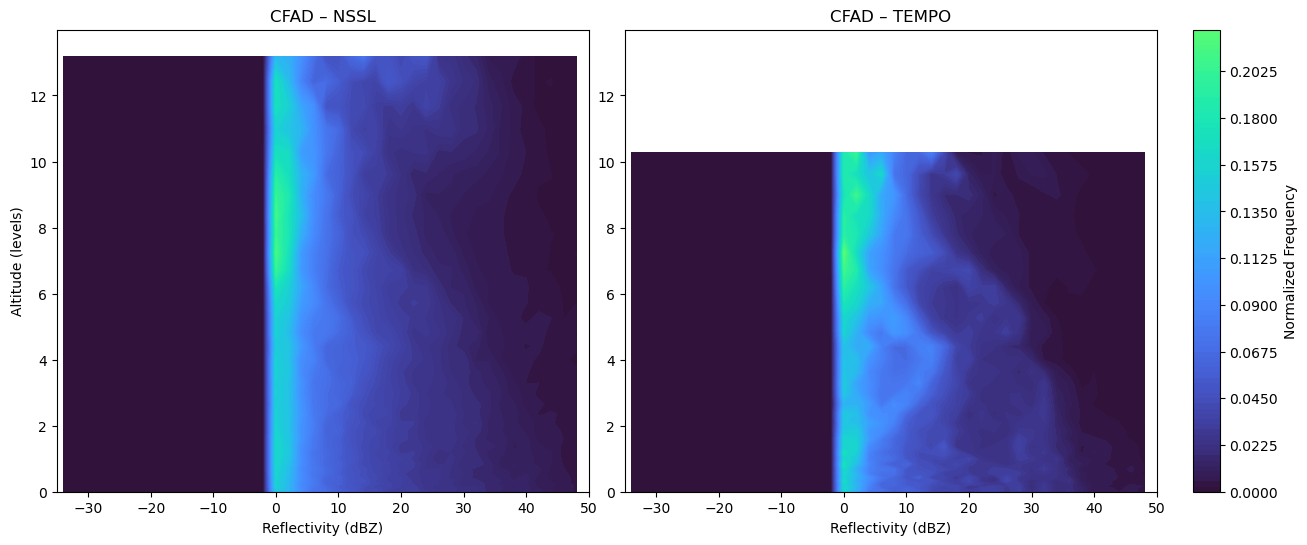

In [280]:
fig = PlotCFAD(radarNSSL,radarTEMPO)

In [97]:
cfad, z_edges, dbz_edges = create_cfad_gridded(
    radar_gridded = radarNSSL.values,            # shape (56, 500, 500)
    altitude_levels = radarNSSL.nVertLevels.values,   # shape (56,)
    field_bins = np.arange(-35, 51, 1),   # dBZ bins
    altitude_bins = np.arange(0, len(radarNSSL.nVertLevels) + 1)
)

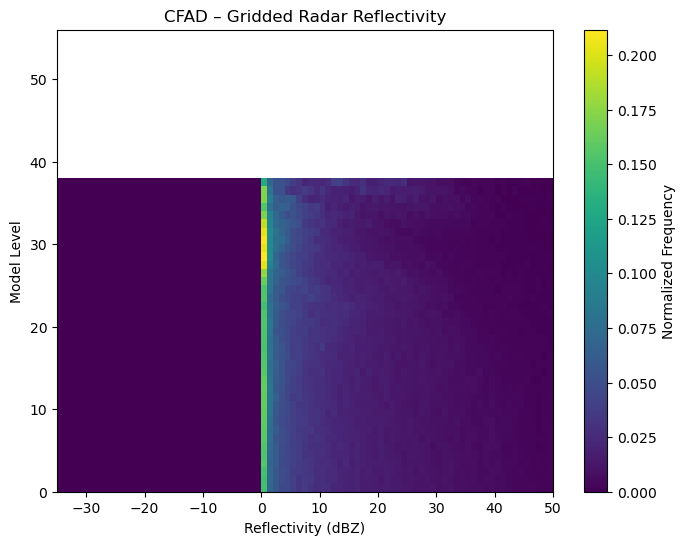

In [98]:
import matplotlib.pyplot as plt
import numpy as np

# Bin centers
z_centers   = 0.5 * (z_edges[:-1] + z_edges[1:])
dbz_centers = 0.5 * (dbz_edges[:-1] + dbz_edges[1:])

plt.figure(figsize=(8, 6))

# pcolormesh uses edges, so use edges directly
plt.pcolormesh(dbz_edges, z_edges, cfad, shading="auto")

plt.xlabel("Reflectivity (dBZ)")
plt.ylabel("Model Level")
plt.title("CFAD – Gridded Radar Reflectivity")

cbar = plt.colorbar()
cbar.set_label("Normalized Frequency")

plt.show()
